<a href="https://colab.research.google.com/github/maks-t-code/predicting_student_health_risk/blob/main/Predicting_Student_Health_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [33]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
def load_dataset() -> pd.DataFrame:
  '''
  Функция скачивает данные с сайта kaggle
  Возвращает:
      - pd.DataFrame

  '''


  !kaggle competitions download -c playground-series-s6e7

  zip_ref = zipfile.ZipFile('playground-series-s6e7.zip', 'r')
  zip_ref.extractall()
  zip_ref.close()
  df_train = pd.read_csv('train.csv')
  df_test = pd.read_csv('test.csv')
  df_sample_submission = pd.read_csv('sample_submission.csv')
  return df_train, df_test, df_sample_submission

In [35]:
df_train, df_test, df_sample_submission = load_dataset()

playground-series-s6e7.zip: Skipping, found more recently modified local copy (use --force to force download)


###Описание признаков

- id — уникальный идентификатор записи.
- health_condition — состояние здоровья (Целевая переменная)
- sleep_duration — продолжительность сна (в часах)
- heart_rate — частота сердечных сокращений (ударов в минуту)
- bmi — индекс массы тела (BMI)
- calorie_expenditure — расход калорий за день (в ккал)
- step_count — количество шагов в день
- exercise_duration — продолжительность физических упражнений (в минутах)
- water_intake — потребление воды (в литрах)
- diet_type — тип питания
- stress_level — уровень стресса
- sleep_quality — качество сна
- physical_activity_level — уровень физической активности
- smoking_alcohol — употребление алкоголя и курения
- gender — пол

#Разведочный анализ данных

In [36]:
df_train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [37]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

Определим целевую переменную

In [38]:
target = 'health_condition'

Проанализируем целевую переменную

In [39]:
df_train[target].unique()

array(['unhealthy', 'at-risk', 'fit'], dtype=object)

In [40]:
# Для обучения модели необходимо целевую переменную закодировать в число
dict_personality = {'unhealthy': 0, 'at-risk': 1, 'fit': 2}
df_train['int_health_condition'] = df_train['health_condition'].map(dict_personality)
target = 'int_health_condition'

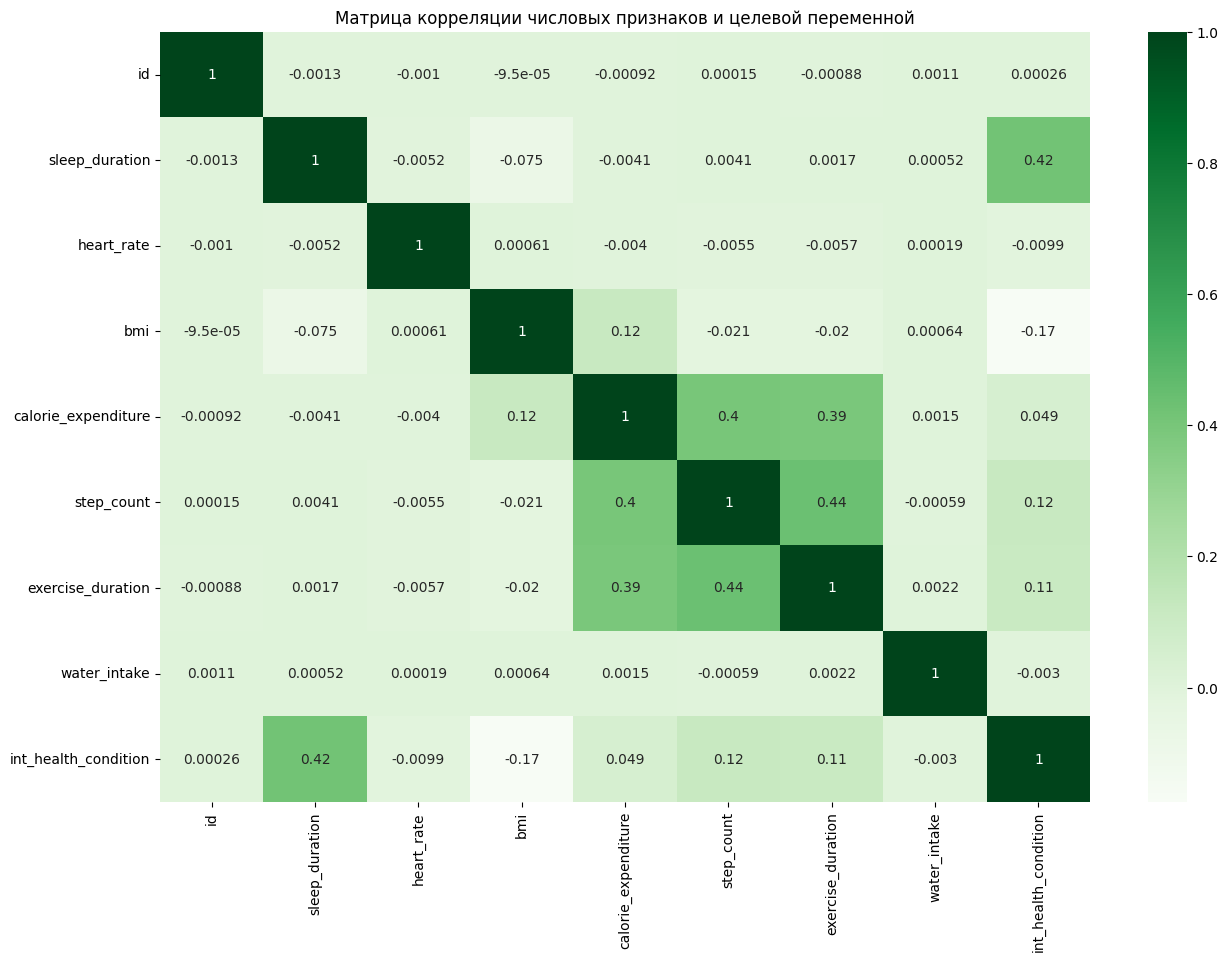

In [41]:
# Посторим тепловую карту линейной корреляции числовых признаков и целевой переменной
plt.figure(figsize=(15, 10))
sns.heatmap(df_train.drop(['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'health_condition'], axis=1).corr(), annot=True, cmap="Greens")
plt.title('Матрица корреляции числовых признаков и целевой переменной')
plt.show()

In [42]:
df_train.isna().sum()

,0
id,0
health_condition,0
sleep_duration,75999
heart_rate,7833
bmi,13898
calorie_expenditure,52853
step_count,13916
exercise_duration,6901
water_intake,43477
diet_type,6901


In [43]:
# Разделение признаков и целевой переменной
X = df_train.drop(['id', 'health_condition', target], axis=1)
y = df_train[target]

In [45]:
# Определяем категориальные и числовые признаки
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(include=np.number).columns
print(list(cat_features))
print(list(num_features))

['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']


In [48]:
X.describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000
